In [46]:
#importaciones iniciales

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

sns.set()

In [47]:
#carga del dataset desde el mismo kaggle
path = kagglehub.dataset_download("austinreese/craigslist-carstrucks-data")

print(os.listdir(path))

df = pd.read_csv(os.path.join(path, "vehicles.csv"))

Using Colab cache for faster access to the 'craigslist-carstrucks-data' dataset.
['vehicles.csv']


## 1. Análisis Exploratorio Inicial
Procedemos a realizar un analisis exploratorio inicial con las tipizas funciones de exploración de Pandas.

In [48]:
#nos muestra el tamaño real de filas y columnas del dataset
df.shape

(426880, 26)

In [49]:
#nos muestra las primeras 5 filas, la tipica
df.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [50]:
#nos muestra el tipo d dato d cada columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [51]:
#nos muestra estadísticas básicas
df.describe()

,id,price,year,odometer,county,lat,long
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05,0.0,420331.000000,420331.000000
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04,NaN,38.493940,-94.748599
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05,NaN,5.841533,18.365462
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04,NaN,34.601900,-111.939847
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04,NaN,39.150100,-88.432600
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05,NaN,42.398900,-80.832039
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502


###Entonces..

A partir del análisis estadístico del dataset con `describe()`, se pueden identificar varias características relevantes de las variables numéricas.

En primer lugar, la variable `price` presenta una gran dispersión, con un promedio de 75,199 y una mediana de 13,950. Esta gran diferencia indica que la distribución está fuertemente sesgada, lo que sugiere la presencia de valores atípicos. Confirmándose esto al observar un valor máximo extremadamente alto (3,736,928,711), el cual no es realista para el precio de un vehículo.

De manera similar, la variable `odometer` presenta valores máximos poco realistas, alcanzando hasta 10,000,000, lo que indica posibles errores en los datos o registros anómalos.

En cuanto al año, o `year`, se observan valores mínimos como 1900, lo que podría corresponder a datos erróneos o vehículos no representativos del mercado actual, como conjetura.

Por otro lado, las variables geográficas de `lat` y `long` presentan valores extremos que podrían indicar errores en la localización de algunos registros, tales como lat: -84 y long: 173.

Respecto a la estructura del dataset, con `info()`, se observa que contiene 426,880 registros y 26 columnas, incluyendo variables numéricas y categóricas.

Además, se identifican varias columnas con una gran cantidad de valores nulos, tales como `condition`, `cylinders`, `VIN` y `size`, lo que sugiere la necesidad de aplicar técnicas de limpieza o eliminación de variables.

Destaca particularmente la columna `county`, la cual no contiene ningún valor válido, por lo que no aporta información al análisis y puede ser eliminada.

En conjunto, este análisis preliminar evidencia la necesidad de realizar un proceso de preprocesamiento de datos, enfocado en la eliminación de valores atípicos, tratamiento de datos faltantes y selección de variables relevantes.

## 2. Análisis de Valores Nulos

In [52]:
#Cantida de valores nulos
df.isnull().sum()

,0
id,0
url,0
region,0
region_url,0
price,0
year,1205
manufacturer,17646
model,5277
condition,174104
cylinders,177678


In [53]:
#porcentaje de valore nulos
(df.isnull().sum() / len(df)) * 100

,0
id,0.000000
url,0.000000
region,0.000000
region_url,0.000000
price,0.000000
year,0.282281
manufacturer,4.133714
model,1.236179
condition,40.785232
cylinders,41.622470


In [54]:
#nos muestra la cardinalida
df.nunique().sort_values(ascending=False)

,0
id,426880
url,426880
posting_date,381536
description,360911
image_url,241899
VIN,118264
odometer,104870
long,53772
lat,53181
model,29667


###Entonces...

Tras realizar un análisis de valores faltantes utilizando las funciones `isnull().sum()` y el cálculo de porcentaje de valores nulos por columna se identifican distintos niveles de completitud en el dataset.

En primer lugar, la columna `county` presenta un 100% de valores nulos, lo que indica que no contiene información útil y puede ser eliminada directamente.

Por otro lado, existen columnas con un porcentaje muy alto de datos faltantes, como `size` con un 71.7%, lo que dificulta su utilización en el análisis, siendo candidata a eliminación.

Asimismo, se identifican varias columnas con una cantidad considerable de valores nulos, entre ellas `cylinders` con un 41.6%, `condition` con un 40.7%, `VIN` con un 37.7%, `drive` con un 30.5% y `paint_color` con un 30.5%. Estas variables podrían ser relevantes, pero requieren un tratamiento más avanzado o podrían ser descartadas para simplificar el análisis.

También se observan columnas con un nivel moderado de valores faltantes, como `type` con un 21.7%, las cuales aún podrían ser utilizadas dependiendo del enfoque del análisis.

En contraste, variables como `year`, `manufacturer`, `model`, `odometer`, `fuel` y `transmission` presentan un bajo porcentaje de valores nulos, menor al 5%, lo que las hace adecuadas para el análisis sin necesidad de un tratamiento complejo.

En general, este análisis permite identificar qué variables son confiables, cuáles requieren limpieza y cuáles pueden ser eliminadas, constituyendo una etapa clave previa al preprocesamiento de los datos.

Por su parte, en cuanto a la cardinalidad, vemos que no tenemos precio realmente únicos ya que son solo unos 15.000 diferentes, por lo que muchos modelos compartiran precio. En cuanto a otras variables como el odometro los datos sí son dispares. E, interpretando otras variables, vemos que hay 114 años distintos, que hay muchos modelos distintos de vehiculos, y en cuanto a categorias tenemos 3 tipos de transmisión, 5 tipos de combustible, entre otras.
A su vez, se identifica que la columna país `country`está completamente vacía x lo cula se descarta su uso inmediatamente.

## 3. Visualizaciones
Una forma de ver la vida con otros ojos...

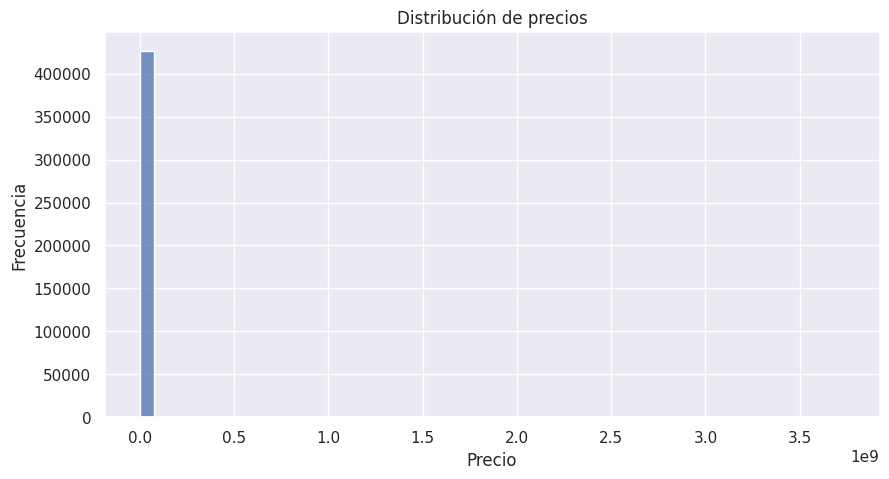

In [55]:
#distribucion de precios

plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=50)
plt.title('Distribución de precios')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

Visualizar los precios así es absurdo, dado los outlier que hay se aprecia una deficiente muestra visual...
Así que se decide y procede a filtrar para una mejor visualización.
Y qué es el absurdo, sino la vida misma...

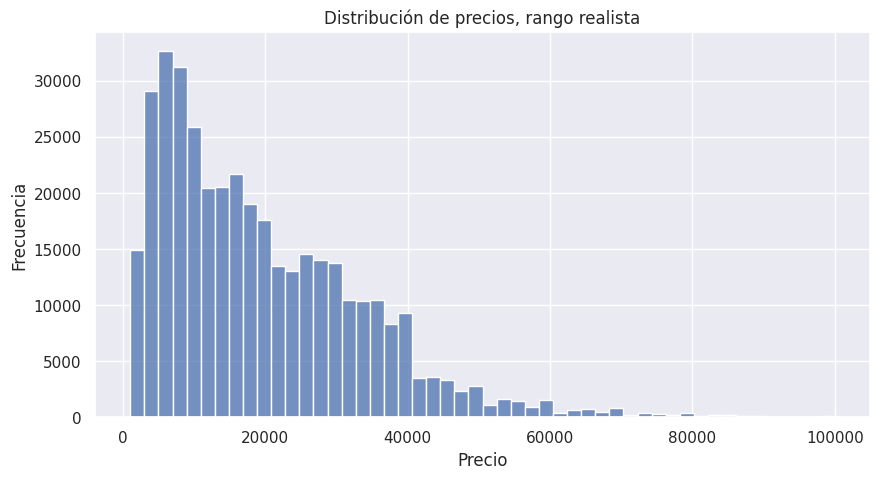

In [56]:
#distribucion de precios filtrada, sin outlier
df_price_clean = df[(df['price'] > 1000) & (df['price'] < 100000)]

plt.figure(figsize=(10,5))
sns.histplot(df_price_clean['price'], bins=50)
plt.title('Distribución de precios, rango realista')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

Ahora sí se aprecia de mejor forma que los precios están concentrados entre los 5000 a 20000 dólares.

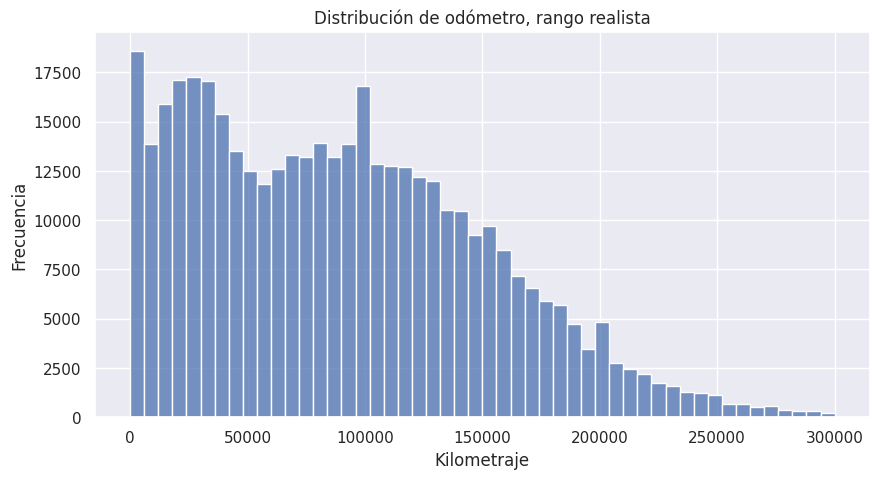

In [57]:
#distribucion de odometro filtrada, sin outlier
df_odo_clean = df[(df['odometer'] > 0) & (df['odometer'] < 300000)]

plt.figure(figsize=(10,5))
sns.histplot(df_odo_clean['odometer'], bins=50)
plt.title('Distribución de odómetro, rango realista')
plt.xlabel('Kilometraje')
plt.ylabel('Frecuencia')
plt.show()

En cuanto al odometro, vemos que gran parte de los vehiculos tienen menos de 50000 kilometros, no obstante la mayoria está entre los 50000 a 150000 kilometros recorridos.

Para las demas celdas crearé una versión "más limpia" del dataset, expresada como `df_clean`, para comparar los gráficos con el total de datos y con los datos sin outliers.

In [58]:
df_clean = df[
    (df['price'] > 1000) & (df['price'] < 100000) &
    (df['odometer'] > 0) & (df['odometer'] < 300000)
]

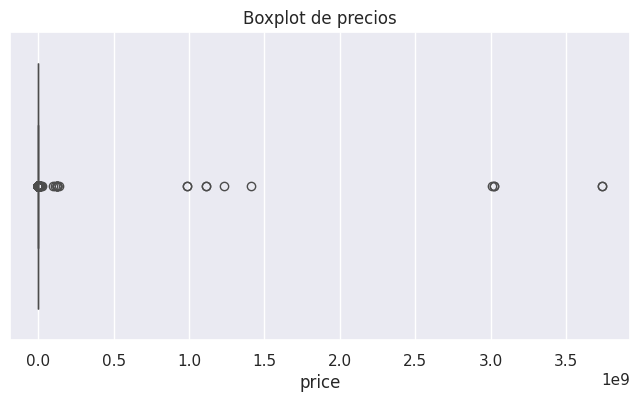

In [59]:
#boxplot precio no filtrado

plt.figure(figsize=(8,4))
sns.boxplot(x=df['price'])
plt.title('Boxplot de precios')
plt.show()

Como se aprecia, los outliers nuevamente hacen de las suyas, imposibilitando una adecuada visualización... como quien reincurre en los actos del ser...
filtrado queda tal que:

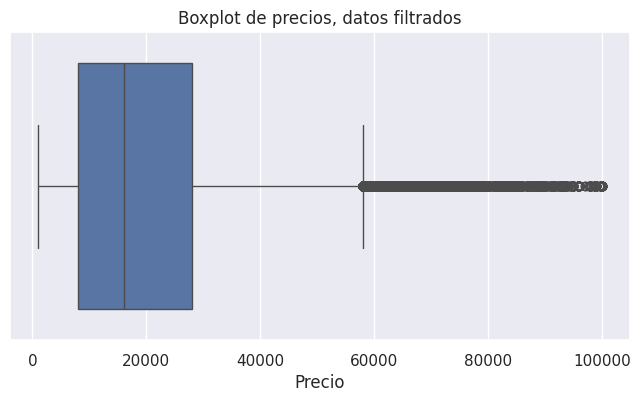

In [60]:
#boxplot precios filtrado

plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean['price'])
plt.title('Boxplot de precios, datos filtrados')
plt.xlabel('Precio')
plt.show()

Como se decía, gran parte de los precios están entre los 5mil a 20mil dolares.

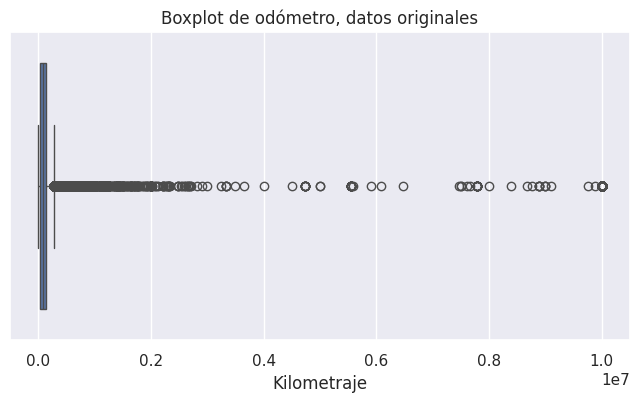

In [61]:
#boxplot odometro sin filtrar

plt.figure(figsize=(8,4))
sns.boxplot(x=df['odometer'])
plt.title('Boxplot de odómetro, datos originales')
plt.xlabel('Kilometraje')
plt.show()

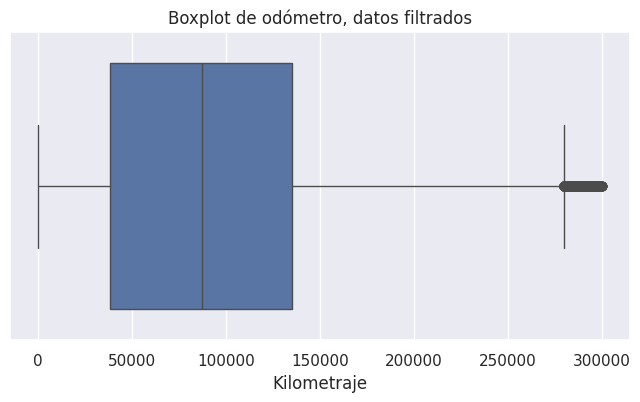

In [62]:
#boxplot odometro filtrado

plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean['odometer'])
plt.title('Boxplot de odómetro, datos filtrados')
plt.xlabel('Kilometraje')
plt.show()

Igualemente para el odometro, concentrados entre los 40000 a 130000 kilometros, estimativamente.

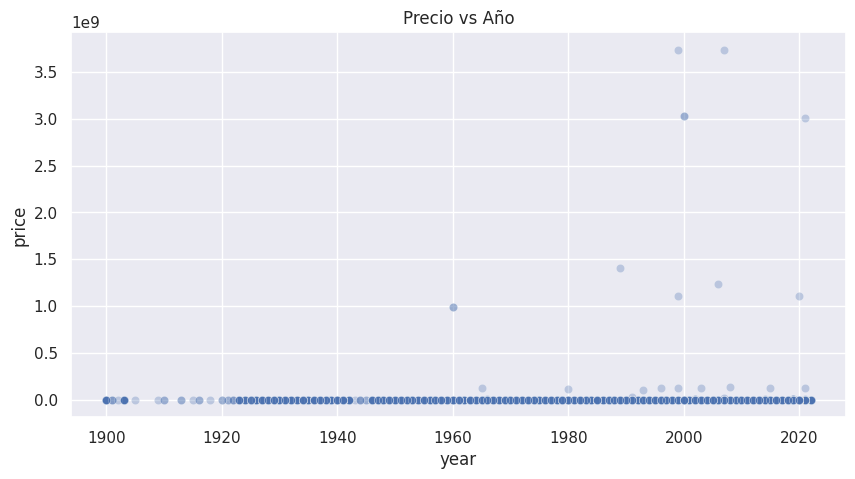

In [63]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='year', y='price', data=df, alpha=0.3)
plt.title('Precio vs Año')
plt.show()

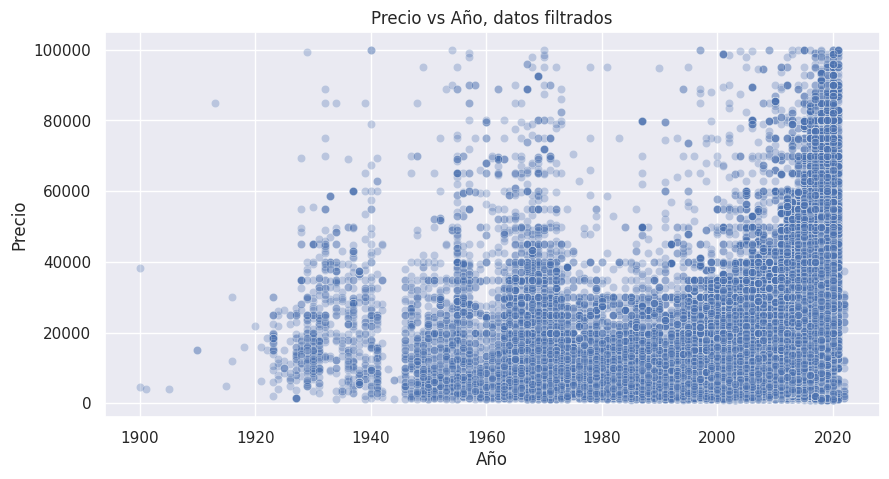

In [64]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='year', y='price', data=df_clean, alpha=0.3)
plt.title('Precio vs Año, datos filtrados')
plt.xlabel('Año')
plt.ylabel('Precio')
plt.show()

Aquí se aprecia que los vehiculos entre mas modernos serán más costosos, como es de esperar, no obstante hay registros que escapan a esto, como la concentración entre las decadas del 50 y 70, siendo estas las "joyitas" el mundo automotriz.

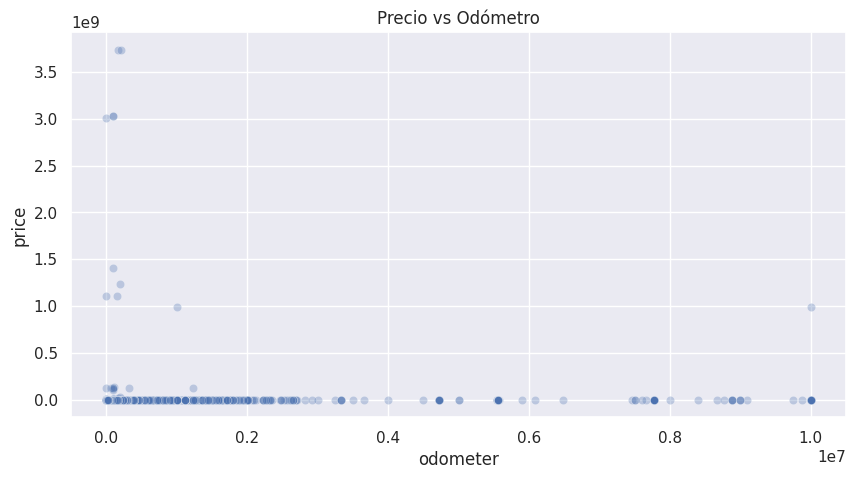

In [65]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='odometer', y='price', data=df, alpha=0.3)
plt.title('Precio vs Odómetro')
plt.show()

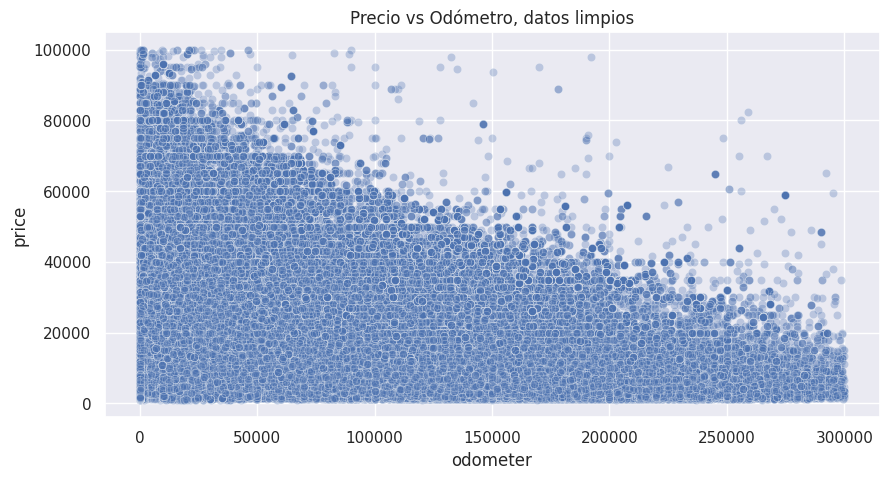

In [66]:
df_clean = df[
    (df['price'] > 1000) & (df['price'] < 100000) &
    (df['odometer'] > 0) & (df['odometer'] < 300000)
]

plt.figure(figsize=(10,5))
sns.scatterplot(x='odometer', y='price', data=df_clean, alpha=0.3)
plt.title('Precio vs Odómetro, datos limpios')
plt.show()

Y, como es totalmente esperable, a media que un vehiculo aumenta su kilometraje pierde drasticamente su valor.

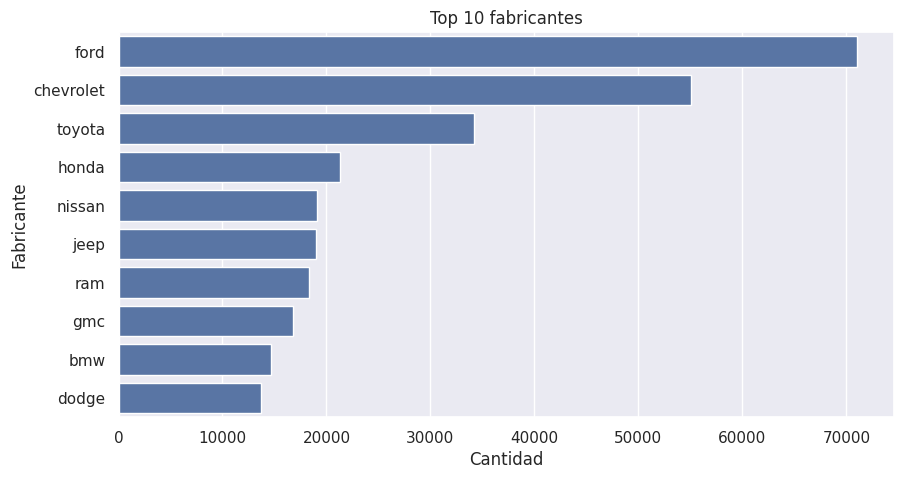

In [68]:
top_manufacturers = df['manufacturer'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_manufacturers.values, y=top_manufacturers.index)
plt.title('Top 10 fabricantes')
plt.xlabel('Cantidad')
plt.ylabel('Fabricante')
plt.show()

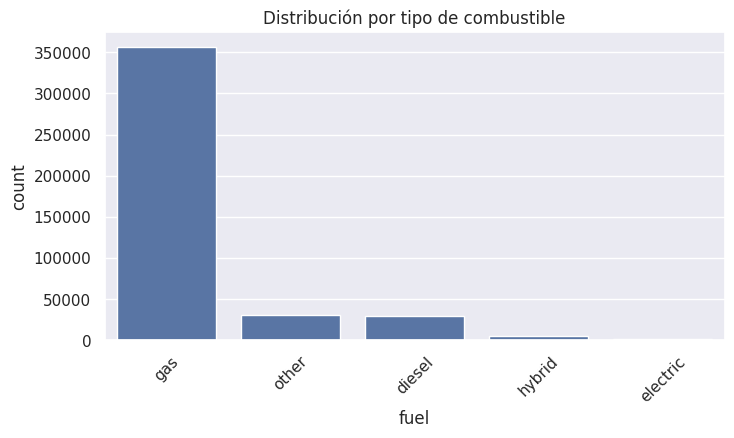

In [69]:
plt.figure(figsize=(8,4))
sns.countplot(x='fuel', data=df)
plt.title('Distribución por tipo de combustible')
plt.xticks(rotation=45)
plt.show()

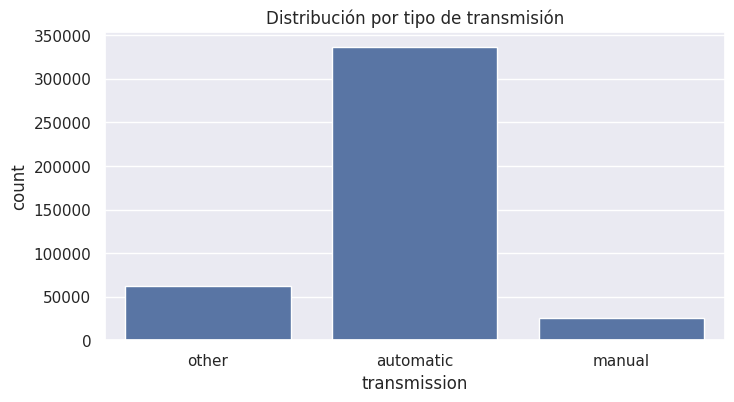

In [70]:
plt.figure(figsize=(8,4))
sns.countplot(x='transmission', data=df)
plt.title('Distribución por tipo de transmisión')
plt.show()

¿Podría ser problemático el hecho de que hay una gran cantidad de automáticos cuando querranmos estimar el precio de los manuales? Lo averiguaremos.

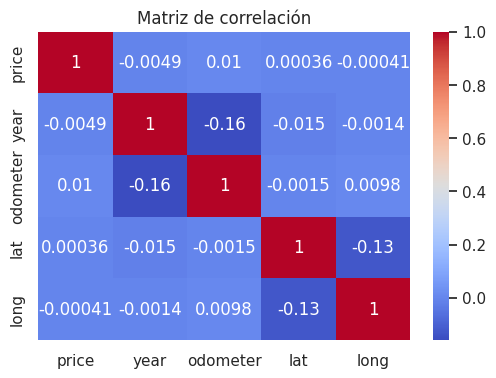

In [71]:
corr = df[['price','year','odometer','lat','long']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

En un principio podríamos pensar que ninguna variable está directamente relacionada al precio, no obstante, esto debe hacernos pensar en que lo que sucede realmente es que el precio de los vehículos se estima mediante la cohesión y consideración de distintas variable, y no en cuanto a una una única, por lo que el precio será el resultado del cruce de distintos factores. Como todo en este santo mundo.